In [36]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor,plot_importance
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")

### Load data 

In [37]:
DATA_PATH_TRAIN=Path("data/train.csv")
DATA_PATH_VAL=Path("data/val.csv")
DATA_PATH_TEST=Path("data/test.csv")
train=pd.read_csv(DATA_PATH_TRAIN,index_col='Date', parse_dates=True)
val=pd.read_csv(DATA_PATH_VAL,index_col='Date', parse_dates=True)
test=pd.read_csv(DATA_PATH_TEST,index_col='Date', parse_dates=True)


In [38]:
train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 913 entries, 2015-11-23 to 2019-05-22
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       913 non-null    float64
 1   Low        913 non-null    float64
 2   Open       913 non-null    float64
 3   Close      913 non-null    float64
 4   Volume     913 non-null    float64
 5   Adj Close  913 non-null    float64
dtypes: float64(6)
memory usage: 49.9 KB


### define target (y=close)

In [39]:
target='Close'

### Baseline models 

#### Naive (tomorrows prediction = todays value)

In [40]:
y_true = val[target]

In [41]:
y_pred = val[target].shift(1)
y_pred.iloc[0] = train[target].iloc[-1]

In [42]:
mae  = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"Naive baseline | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

Naive baseline | MAE: 16.36 | RMSE: 22.43 | MAPE: 0.5427%


In [43]:
results = {}
results['naive_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

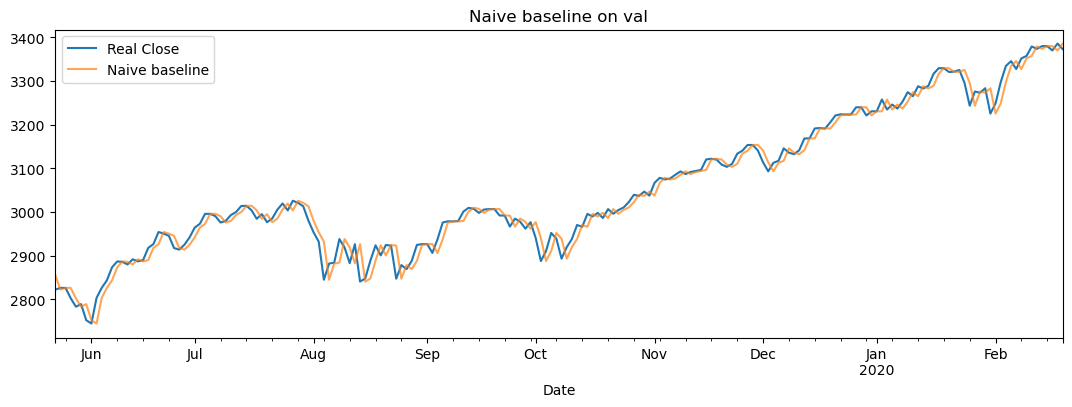

In [44]:
fig, ax = plt.subplots(figsize=(13,4))
y_true.plot(ax=ax, label='Real Close')
y_pred.plot(ax=ax, label='Naive baseline', alpha=0.7)
ax.set_title('Naive baseline on val')
ax.legend()
plt.show()

### Drift

In [45]:
T = len(train)
slope = (train[target].iloc[-1] - train[target].iloc[0]) / (T - 1)
last_train_value = train[target].iloc[-1]

In [46]:
h = np.arange(1, len(val) + 1)
y_pred = pd.Series(last_train_value + h * slope, index=val.index)

In [47]:
y_true = val[target]

In [48]:
mae  = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"Drift baseline | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

Drift baseline | MAE: 127.64 | RMSE: 163.38 | MAPE: 4.0322%


In [49]:
results['drift_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

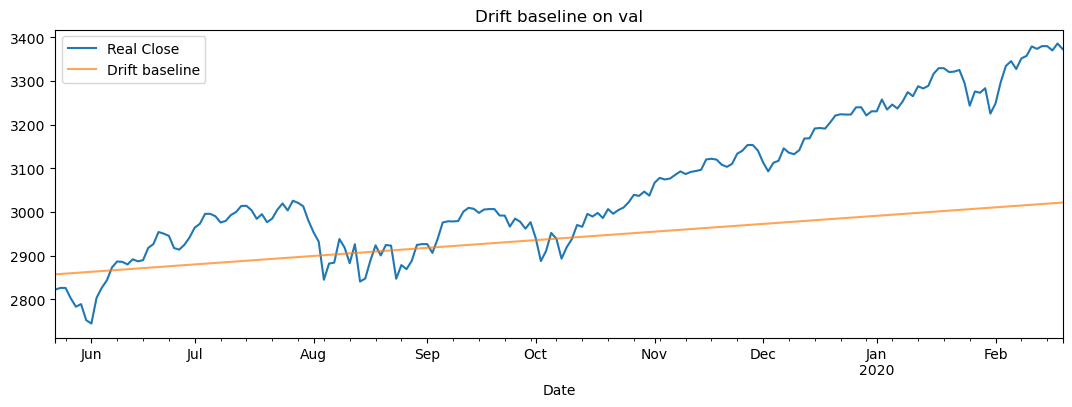

In [50]:
fig, ax = plt.subplots(figsize=(13,4))
y_true.plot(ax=ax, label='Real Close')
y_pred.plot(ax=ax, label='Drift baseline', alpha=0.7)
ax.set_title('Drift baseline on val')
ax.legend()
plt.show()

## ARIMA

In [51]:
model=ARIMA(train[target],order=(1,1,1))
model_fit=model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  913
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4022.837
Date:                Mon, 18 May 2026   AIC                           8051.675
Time:                        17:33:42   BIC                           8066.121
Sample:                    11-23-2015   HQIC                          8057.190
                         - 05-22-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7495      0.242     -3.095      0.002      -1.224      -0.275
ma.L1          0.7806      0.233      3.344      0.001       0.323       1.238
sigma2       396.9857      9.969     39.821      0.000     377.446     416.525
===================================================================================
Ljung-Box (L1) (Q):                   1.58   Jarque-Bera (JB):              1171.66
Prob(Q):                              0.21   Prob(JB):                         0.00
Heteroskedasticity (H):               2.31   Skew:                            -0.68
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [52]:
residuals = pd.DataFrame(model_fit.resid)
residuals.describe()

,0
count,913.000000
mean,3.113645
std,71.842456
min,-111.405072
25%,-5.924845
50%,0.986530
75%,10.185817
max,2086.590088


Text(0, 0.5, 'density')

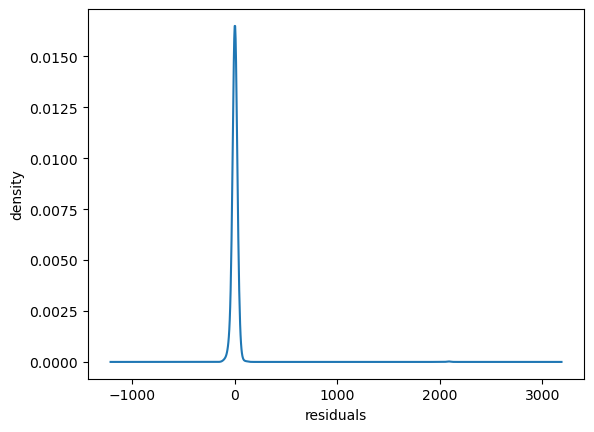

In [53]:
residuals.plot(kind="kde", legend=False)
plt.xlabel("residuals")
plt.ylabel("density")

In [54]:
history = list(train[target].values)
predictions = []
for i in range(len(val)):
    model = ARIMA(history, order=(1, 1, 1))
    model_fit = model.fit() 
    yhat = model_fit.forecast(steps=1)[0]
    predictions.append(yhat) 
    actual=val[target].iloc[i]
    history.append(actual)

y_pred_arima = pd.Series(predictions, index=val.index)
y_true = val[target]

In [55]:
mae  = mean_absolute_error(y_true, y_pred_arima)
rmse = root_mean_squared_error(y_true, y_pred_arima)
mape = mean_absolute_percentage_error(y_true, y_pred_arima)
print(f"ARIMA | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

ARIMA | MAE: 16.45 | RMSE: 22.44 | MAPE: 0.5458%


In [56]:
results['ARIMA_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

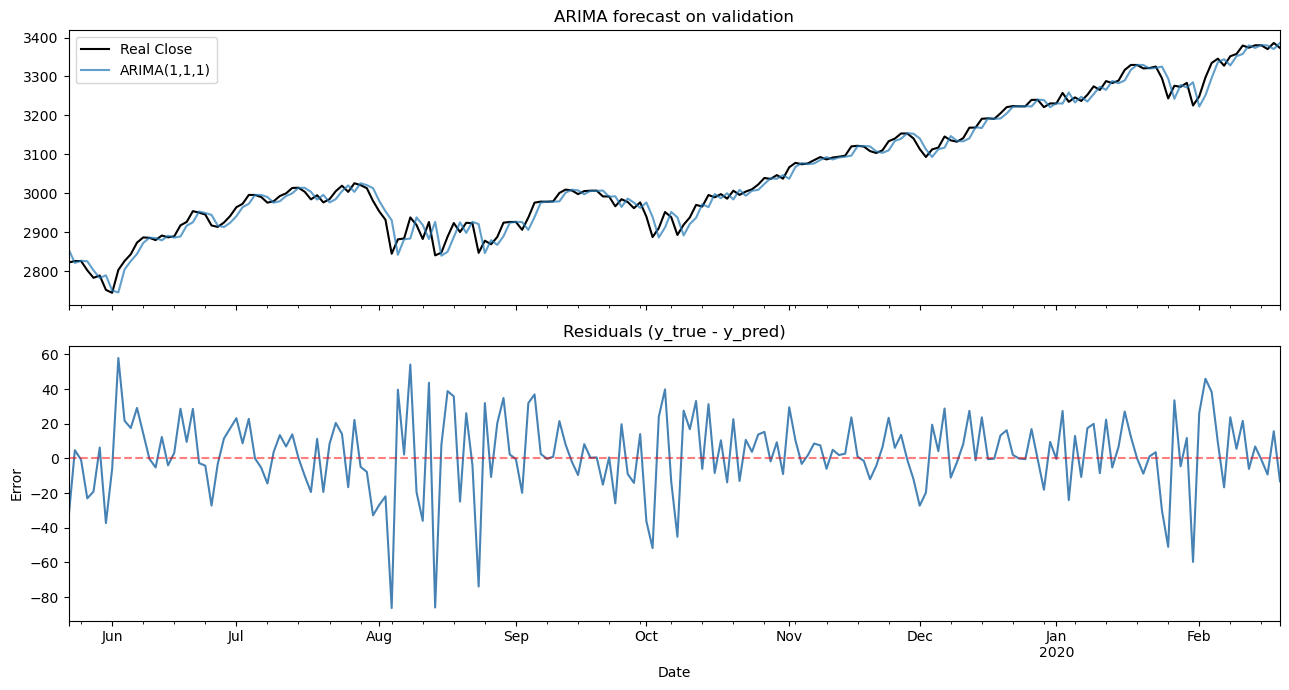

In [57]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

y_true.plot(ax=axes[0], label='Real Close', color='black')
y_pred_arima.plot(ax=axes[0], label='ARIMA(1,1,1)', alpha=0.7)
axes[0].set_title('ARIMA forecast on validation')
axes[0].legend()

residuals = y_true - y_pred_arima
residuals.plot(ax=axes[1], color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Residuals (y_true - y_pred)')
axes[1].set_ylabel('Error')

plt.tight_layout()
plt.show()

##### ARIMA can be 'tuned' using auto_arima, but i move on to XGBoost!

## XGBoost


In [58]:
target_col='Close'

In [59]:
full = pd.concat([train, val, test])

In [60]:
full['target'] = full[target_col].diff().shift(-1)

In [61]:
full['close_lag_1'] = full[target_col].shift(1)
full['close_lag_5'] = full[target_col].shift(5)
full['close_lag_21'] = full[target_col].shift(21)
full['close_ma_7'] = full[target_col].rolling(7).mean()
full['close_ma_21'] = full[target_col].rolling(21).mean()
full['close_std_21'] = full[target_col].rolling(21).std()
full['return_1'] = full[target_col].pct_change(1)
full['return_5'] = full[target_col].pct_change(5)

In [62]:
full = full.dropna()

In [63]:
today_close = full[target_col].copy()

In [64]:
X = full.drop(columns=['target', target_col, 'High', 'Low', 'Open', 'Volume', 'Adj Close'])
y = full['target']

X_train = X.loc[:train.index[-1]]
y_train = y.loc[:train.index[-1]]

X_val   = X.loc[val.index[0]:val.index[-1]]
y_val   = y.loc[val.index[0]:val.index[-1]]

X_test  = X.loc[test.index[0]:]
y_test  = y.loc[test.index[0]:]

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

X_train: (892, 8) | X_val: (196, 8) | X_test: (195, 8)


In [65]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
)
model.fit(X_train, y_train)
y_pred_diff = pd.Series(model.predict(X_val), index=X_val.index)

In [66]:
close_today_val = today_close.loc[X_val.index]
y_pred_close = close_today_val + y_pred_diff
y_true_close = close_today_val + y_val

In [67]:
mae  = mean_absolute_error(y_true_close, y_pred_close)
rmse = root_mean_squared_error(y_true_close, y_pred_close)
mape = mean_absolute_percentage_error(y_true_close, y_pred_close)
print(f"XGBoost | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

results['xgboost_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

XGBoost | MAE: 35.18 | RMSE: 40.19 | MAPE: 1.1436%


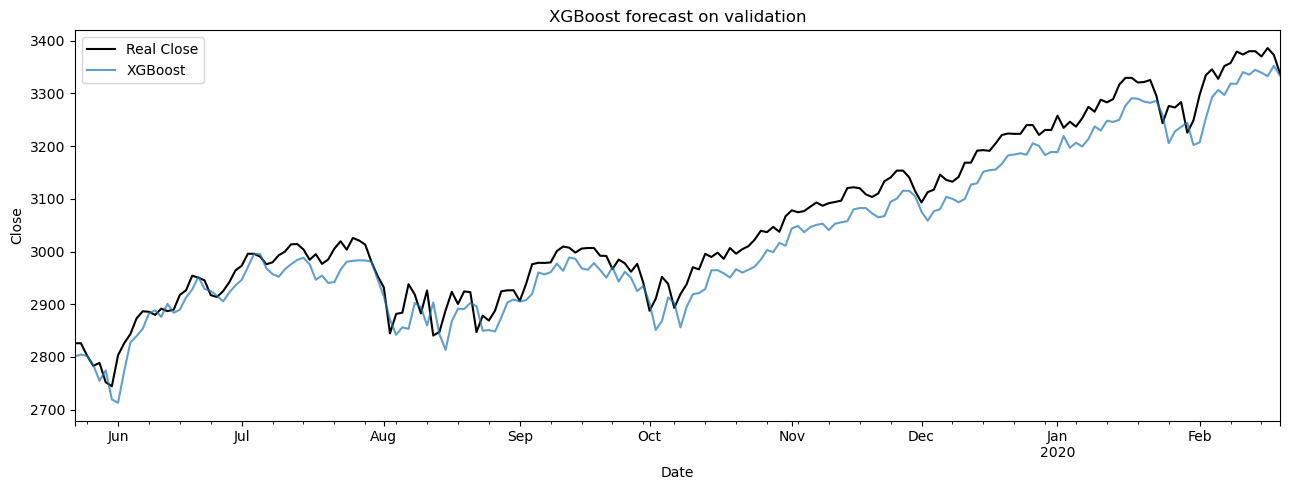

In [68]:
fig, ax = plt.subplots(figsize=(13, 5))
y_true_close.plot(ax=ax, label='Real Close', color='black', linewidth=1.5)
y_pred_close.plot(ax=ax, label='XGBoost', alpha=0.7)
ax.set_title('XGBoost forecast on validation')
ax.set_ylabel('Close')
ax.legend()
plt.tight_layout()
plt.show()

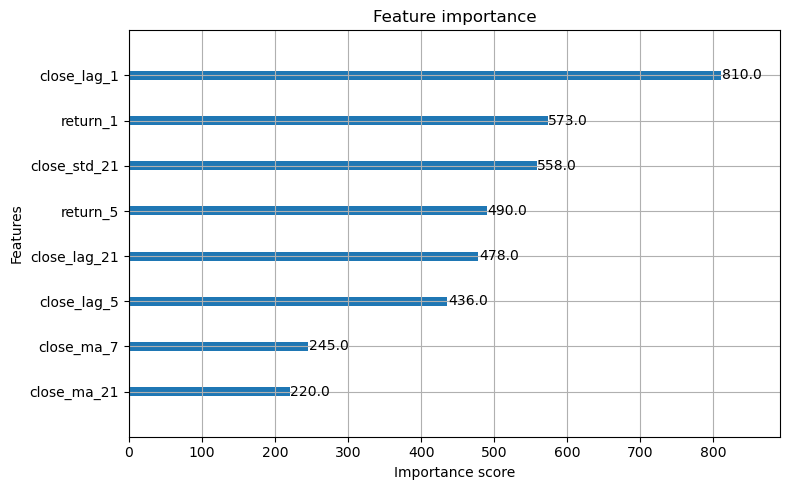

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(model, max_num_features=10, ax=ax)
plt.title('Feature importance')
plt.tight_layout()
plt.show()

### XGBoost tuning (with RandomizedSearchCV) 